In [8]:
import pandas as pd
import numpy as np

# Load AAPL data
data = pd.read_csv("C:/Users/polex/Desktop/Quant/quant-trading-system/data/AAPL.csv")
data.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-02,24.214895248413086,24.68222757163672,23.776355295274307,24.67115267325441,212818400
3,2015-01-05,23.53272247314453,24.064285483437537,23.346676348927705,23.984550947403974,257142000
4,2015-01-06,23.534934997558594,23.794071364016485,23.173914310644687,23.59695036493737,263188400


In [9]:
data.columns = data.columns.str.strip()


In [10]:
# Parse date and sort
if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])
    data = data.sort_values('Date').reset_index(drop=True)

print(data.head())
print(data.columns.tolist())
print(data.shape)

        Price               Close                High                 Low  \
0      Ticker                AAPL                AAPL                AAPL   
1        Date                 NaN                 NaN                 NaN   
2  2015-01-02  24.214895248413086   24.68222757163672  23.776355295274307   
3  2015-01-05   23.53272247314453  24.064285483437537  23.346676348927705   
4  2015-01-06  23.534934997558594  23.794071364016485  23.173914310644687   

                 Open     Volume  
0                AAPL       AAPL  
1                 NaN        NaN  
2   24.67115267325441  212818400  
3  23.984550947403974  257142000  
4   23.59695036493737  263188400  
['Price', 'Close', 'High', 'Low', 'Open', 'Volume']
(2815, 6)


In [15]:

# ── FIX: Clean column names and force numeric types ───────────────────────────
data.columns = data.columns.str.strip()

print("Columns:", data.columns.tolist())
print("Dtypes before fix:\n", data.dtypes)
print("Sample data:\n", data.head())

# Remove commas from numeric columns (e.g. "1,234.56" → 1234.56)
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    if col in data.columns:
        data[col] = data[col].astype(str).str.replace(',', '', regex=False)
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Parse and sort by date
date_col = next((c for c in data.columns if 'date' in c.lower()), None)
if date_col:
    data[date_col] = pd.to_datetime(data[date_col])
    data = data.sort_values(date_col).reset_index(drop=True)

# Drop rows where Close is null
data.dropna(subset=['Close'], inplace=True)

print("\nDtypes after fix:\n", data.dtypes)
print(f"Shape: {data.shape}")
print(data.head())

# ── Returns ───────────────────────────────────────────────────────────────────
data['Return_1d']  = data['Close'].pct_change(1)
data['Return_5d']  = data['Close'].pct_change(5)
data['Return_10d'] = data['Close'].pct_change(10)
data['Return_20d'] = data['Close'].pct_change(20)
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

# ── Moving Averages ───────────────────────────────────────────────────────────
data['SMA_10']  = data['Close'].rolling(window=10).mean()
data['SMA_20']  = data['Close'].rolling(window=20).mean()
data['SMA_50']  = data['Close'].rolling(window=50).mean()
data['SMA_200'] = data['Close'].rolling(window=200).mean()

data['EMA_10'] = data['Close'].ewm(span=10, adjust=False).mean()
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
data['EMA_50'] = data['Close'].ewm(span=50, adjust=False).mean()

data['SMA_10_20_Cross'] = (data['SMA_10'] > data['SMA_20']).astype(int)
data['SMA_20_50_Cross'] = (data['SMA_20'] > data['SMA_50']).astype(int)
data['Price_to_SMA20']  = data['Close'] / data['SMA_20']
data['Price_to_SMA50']  = data['Close'] / data['SMA_50']

# ── Volatility / Bollinger Bands ──────────────────────────────────────────────
data['Volatility_10d'] = data['Log_Return'].rolling(10).std() * np.sqrt(252)
data['Volatility_20d'] = data['Log_Return'].rolling(20).std() * np.sqrt(252)

bb_window = 20
data['BB_Mid']   = data['Close'].rolling(bb_window).mean()
bb_std           = data['Close'].rolling(bb_window).std()
data['BB_Upper'] = data['BB_Mid'] + 2 * bb_std
data['BB_Lower'] = data['BB_Mid'] - 2 * bb_std
data['BB_Width'] = (data['BB_Upper'] - data['BB_Lower']) / data['BB_Mid']
data['BB_Pct']   = (data['Close'] - data['BB_Lower']) / (data['BB_Upper'] - data['BB_Lower'])

# ATR
data['TR'] = np.maximum(
    data['High'] - data['Low'],
    np.maximum(
        abs(data['High'] - data['Close'].shift(1)),
        abs(data['Low']  - data['Close'].shift(1))
    )
)
data['ATR_14'] = data['TR'].rolling(14).mean()

# ── Momentum ──────────────────────────────────────────────────────────────────
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

data['RSI_14'] = compute_rsi(data['Close'], 14)
data['RSI_7']  = compute_rsi(data['Close'],  7)

ema_12 = data['Close'].ewm(span=12, adjust=False).mean()
ema_26 = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD']        = ema_12 - ema_26
data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()
data['MACD_Hist']   = data['MACD'] - data['MACD_Signal']

stoch_low  = data['Low'].rolling(14).min()
stoch_high = data['High'].rolling(14).max()
data['Stoch_K']    = 100 * (data['Close'] - stoch_low) / (stoch_high - stoch_low + 1e-10)
data['Stoch_D']    = data['Stoch_K'].rolling(3).mean()
data['Williams_R'] = -100 * (stoch_high - data['Close']) / (stoch_high - stoch_low + 1e-10)
data['ROC_10']     = data['Close'].pct_change(10) * 100
data['ROC_20']     = data['Close'].pct_change(20) * 100

# ── Volume ────────────────────────────────────────────────────────────────────
if 'Volume' in data.columns:
    data['Volume_SMA_20'] = data['Volume'].rolling(20).mean()
    data['Volume_Ratio']  = data['Volume'] / (data['Volume_SMA_20'] + 1e-10)
    data['OBV']           = (np.sign(data['Close'].diff()) * data['Volume']).fillna(0).cumsum()

# ── Candle structure ──────────────────────────────────────────────────────────
data['High_Low_Range'] = (data['High'] - data['Low']) / data['Close']
data['Body_Size']      = abs(data['Close'] - data['Open']) / data['Close']
data['Gap']            = (data['Open'] - data['Close'].shift(1)) / data['Close'].shift(1)

# ── Target ────────────────────────────────────────────────────────────────────
data['Target']       = (data['Close'].shift(-1) > data['Close']).astype(int)
data['Target_Return'] = data['Close'].shift(-1) / data['Close'] - 1

# ── Cleanup ───────────────────────────────────────────────────────────────────
data.drop(columns=['TR'], inplace=True, errors='ignore')
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

print(f"\n✅ Done! Shape: {data.shape}")
print(f"Features: {data.shape[1]}")
data.head()

Columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']
Dtypes before fix:
 Price     str
Close     str
High      str
Low       str
Open      str
Volume    str
dtype: object
Sample data:
         Price               Close                High                 Low  \
0      Ticker                AAPL                AAPL                AAPL   
1        Date                 NaN                 NaN                 NaN   
2  2015-01-02  24.214895248413086   24.68222757163672  23.776355295274307   
3  2015-01-05   23.53272247314453  24.064285483437537  23.346676348927705   
4  2015-01-06  23.534934997558594  23.794071364016485  23.173914310644687   

                 Open     Volume  
0                AAPL       AAPL  
1                 NaN        NaN  
2   24.67115267325441  212818400  
3  23.984550947403974  257142000  
4   23.59695036493737  263188400  

Dtypes after fix:
 Price         str
Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype:

,Price,Close,High,Low,Open,Volume,Return_1d,Return_5d,Return_10d,Return_20d,...,ROC_10,ROC_20,Volume_SMA_20,Volume_Ratio,OBV,High_Low_Range,Body_Size,Gap,Target,Target_Return
0,2015-10-16,24.906059,25.121385,24.791667,25.072039,156930400.0,-0.007330,-0.009633,0.005980,-0.021243,...,0.597966,-2.124260,200650080.0,0.782110,-543586800.0,0.013238,0.006664,-0.000715,1,0.006214
1,2015-10-19,25.060825,25.065311,24.697462,24.852228,119036800.0,0.006214,0.001165,0.008575,-0.030206,...,0.857548,-3.020551,196557520.0,0.605608,-424550000.0,0.014678,0.008324,-0.002161,1,0.018258
2,2015-10-20,25.518387,25.608106,24.856708,24.973343,195871200.0,0.018258,0.017712,0.022100,0.003263,...,2.210028,0.326288,196281840.0,0.997908,-228678800.0,0.029445,0.021359,-0.003491,0,-0.000088
3,2015-10-21,25.516142,25.924364,25.502683,25.569973,167180800.0,-0.000088,0.032211,0.026900,-0.004899,...,2.689974,-0.489859,197489540.0,0.846530,-395859600.0,0.016526,0.002110,0.002022,1,0.015296
4,2015-10-22,25.906427,25.906427,25.592410,25.643999,166616400.0,0.015296,0.032541,0.054795,0.004348,...,5.479471,0.434787,195776460.0,0.851054,-229243200.0,0.012121,0.010130,0.005011,1,0.030996


In [16]:
import pandas as pd
import numpy as np
import os

# ── Folders ───────────────────────────────────────────────────────────────────
data_folder     = "C:/Users/polex/Desktop/Quant/quant-trading-system/data"
features_folder = "C:/Users/polex/Desktop/Quant/quant-trading-system/features"
os.makedirs(features_folder, exist_ok=True)

# ── Function: RSI ─────────────────────────────────────────────────────────────
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

# ── Loop Over All CSVs ────────────────────────────────────────────────────────
stock_files = [f for f in os.listdir(data_folder) if f.endswith(".csv")]

for stock_file in stock_files:
    stock_name = stock_file.replace(".csv", "")
    print(f"\nProcessing {stock_name}...")

    # Load
    data = pd.read_csv(os.path.join(data_folder, stock_file))
    data.columns = data.columns.str.strip()

    # Fix numeric columns
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        if col in data.columns:
            data[col] = data[col].astype(str).str.replace(',', '', regex=False)
            data[col] = pd.to_numeric(data[col], errors='coerce')

    # Parse and sort date
    date_col = next((c for c in data.columns if 'date' in c.lower()), None)
    if date_col:
        data[date_col] = pd.to_datetime(data[date_col])
        data = data.sort_values(date_col).reset_index(drop=True)

    # Drop rows where Close is null
    data.dropna(subset=['Close'], inplace=True)

    # ── Returns ────────────────────────────────────────────────────────────────
    data['Return_1d']  = data['Close'].pct_change(1)
    data['Return_5d']  = data['Close'].pct_change(5)
    data['Return_10d'] = data['Close'].pct_change(10)
    data['Return_20d'] = data['Close'].pct_change(20)
    data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

    # ── Moving Averages ────────────────────────────────────────────────────────
    data['SMA_10']  = data['Close'].rolling(10).mean()
    data['SMA_20']  = data['Close'].rolling(20).mean()
    data['SMA_50']  = data['Close'].rolling(50).mean()
    data['SMA_200'] = data['Close'].rolling(200).mean()

    data['EMA_10'] = data['Close'].ewm(span=10, adjust=False).mean()
    data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
    data['EMA_50'] = data['Close'].ewm(span=50, adjust=False).mean()

    data['SMA_10_20_Cross'] = (data['SMA_10'] > data['SMA_20']).astype(int)
    data['SMA_20_50_Cross'] = (data['SMA_20'] > data['SMA_50']).astype(int)
    data['Price_to_SMA20']  = data['Close'] / data['SMA_20']
    data['Price_to_SMA50']  = data['Close'] / data['SMA_50']

    # ── Volatility / Bollinger Bands ──────────────────────────────────────────
    data['Volatility_10d'] = data['Log_Return'].rolling(10).std() * np.sqrt(252)
    data['Volatility_20d'] = data['Log_Return'].rolling(20).std() * np.sqrt(252)

    bb_window = 20
    data['BB_Mid']   = data['Close'].rolling(bb_window).mean()
    bb_std           = data['Close'].rolling(bb_window).std()
    data['BB_Upper'] = data['BB_Mid'] + 2 * bb_std
    data['BB_Lower'] = data['BB_Mid'] - 2 * bb_std
    data['BB_Width'] = (data['BB_Upper'] - data['BB_Lower']) / data['BB_Mid']
    data['BB_Pct']   = (data['Close'] - data['BB_Lower']) / (data['BB_Upper'] - data['BB_Lower'])

    # ATR
    data['TR'] = np.maximum(
        data['High'] - data['Low'],
        np.maximum(
            abs(data['High'] - data['Close'].shift(1)),
            abs(data['Low']  - data['Close'].shift(1))
        )
    )
    data['ATR_14'] = data['TR'].rolling(14).mean()

    # ── Momentum ──────────────────────────────────────────────────────────────
    data['RSI_14'] = compute_rsi(data['Close'], 14)
    data['RSI_7']  = compute_rsi(data['Close'], 7)

    ema_12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = data['Close'].ewm(span=26, adjust=False).mean()
    data['MACD']        = ema_12 - ema_26
    data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()
    data['MACD_Hist']   = data['MACD'] - data['MACD_Signal']

    stoch_low  = data['Low'].rolling(14).min()
    stoch_high = data['High'].rolling(14).max()
    data['Stoch_K']    = 100 * (data['Close'] - stoch_low) / (stoch_high - stoch_low + 1e-10)
    data['Stoch_D']    = data['Stoch_K'].rolling(3).mean()
    data['Williams_R'] = -100 * (stoch_high - data['Close']) / (stoch_high - stoch_low + 1e-10)
    data['ROC_10']     = data['Close'].pct_change(10) * 100
    data['ROC_20']     = data['Close'].pct_change(20) * 100

    # ── Volume ────────────────────────────────────────────────────────────────
    if 'Volume' in data.columns:
        data['Volume_SMA_20'] = data['Volume'].rolling(20).mean()
        data['Volume_Ratio']  = data['Volume'] / (data['Volume_SMA_20'] + 1e-10)
        data['OBV']           = (np.sign(data['Close'].diff()) * data['Volume']).fillna(0).cumsum()

    # ── Candle structure ──────────────────────────────────────────────────────
    data['High_Low_Range'] = (data['High'] - data['Low']) / data['Close']
    data['Body_Size']      = abs(data['Close'] - data['Open']) / data['Close']
    data['Gap']            = (data['Open'] - data['Close'].shift(1)) / data['Close'].shift(1)

    # ── Target ───────────────────────────────────────────────────────────────
    data['Target']        = (data['Close'].shift(-1) > data['Close']).astype(int)
    data['Target_Return'] = data['Close'].shift(-1) / data['Close'] - 1

    # ── Cleanup ──────────────────────────────────────────────────────────────
    data.drop(columns=['TR'], inplace=True, errors='ignore')
    data.dropna(inplace=True)
    data.reset_index(drop=True, inplace=True)

    # Save features
    feature_file = os.path.join(features_folder, f"{stock_name}_features.csv")
    data.to_csv(feature_file, index=False)
    print(f"{stock_name} features saved. ✅ Shape: {data.shape}")


Processing AAPL...
AAPL features saved. ✅ Shape: (2613, 48)

Processing AMZN...
AMZN features saved. ✅ Shape: (2613, 48)

Processing GOOGL...
GOOGL features saved. ✅ Shape: (2613, 48)

Processing MSFT...
MSFT features saved. ✅ Shape: (2613, 48)

Processing SPY...
SPY features saved. ✅ Shape: (2613, 48)


In [17]:
import pandas as pd
import numpy as np
import os

# ── Folders ───────────────────────────────────────────────────────────────────
data_folder     = "C:/Users/polex/Desktop/Quant/quant-trading-system/data"
features_folder = "C:/Users/polex/Desktop/Quant/quant-trading-system/features"
os.makedirs(features_folder, exist_ok=True)

# ── Function: RSI ─────────────────────────────────────────────────────────────
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

# ── Loop Over All CSVs ────────────────────────────────────────────────────────
stock_files = [f for f in os.listdir(data_folder) if f.endswith(".csv")]

combined_list = []

for stock_file in stock_files:
    stock_name = stock_file.replace(".csv", "")
    print(f"\nProcessing {stock_name}...")

    # Load
    data = pd.read_csv(os.path.join(data_folder, stock_file))
    data.columns = data.columns.str.strip()

    # Fix numeric columns
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        if col in data.columns:
            data[col] = data[col].astype(str).str.replace(',', '', regex=False)
            data[col] = pd.to_numeric(data[col], errors='coerce')

    # Parse and sort date
    date_col = next((c for c in data.columns if 'date' in c.lower()), None)
    if date_col:
        data[date_col] = pd.to_datetime(data[date_col])
        data = data.sort_values(date_col).reset_index(drop=True)

    # Drop rows where Close is null
    data.dropna(subset=['Close'], inplace=True)

    # ── Returns ────────────────────────────────────────────────────────────────
    data['Return_1d']  = data['Close'].pct_change(1)
    data['Return_5d']  = data['Close'].pct_change(5)
    data['Return_10d'] = data['Close'].pct_change(10)
    data['Return_20d'] = data['Close'].pct_change(20)
    data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

    # ── Moving Averages ────────────────────────────────────────────────────────
    data['SMA_10']  = data['Close'].rolling(10).mean()
    data['SMA_20']  = data['Close'].rolling(20).mean()
    data['SMA_50']  = data['Close'].rolling(50).mean()
    data['SMA_200'] = data['Close'].rolling(200).mean()

    data['EMA_10'] = data['Close'].ewm(span=10, adjust=False).mean()
    data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
    data['EMA_50'] = data['Close'].ewm(span=50, adjust=False).mean()

    data['SMA_10_20_Cross'] = (data['SMA_10'] > data['SMA_20']).astype(int)
    data['SMA_20_50_Cross'] = (data['SMA_20'] > data['SMA_50']).astype(int)
    data['Price_to_SMA20']  = data['Close'] / data['SMA_20']
    data['Price_to_SMA50']  = data['Close'] / data['SMA_50']

    # ── Volatility / Bollinger Bands ──────────────────────────────────────────
    data['Volatility_10d'] = data['Log_Return'].rolling(10).std() * np.sqrt(252)
    data['Volatility_20d'] = data['Log_Return'].rolling(20).std() * np.sqrt(252)

    bb_window = 20
    data['BB_Mid']   = data['Close'].rolling(bb_window).mean()
    bb_std           = data['Close'].rolling(bb_window).std()
    data['BB_Upper'] = data['BB_Mid'] + 2 * bb_std
    data['BB_Lower'] = data['BB_Mid'] - 2 * bb_std
    data['BB_Width'] = (data['BB_Upper'] - data['BB_Lower']) / data['BB_Mid']
    data['BB_Pct']   = (data['Close'] - data['BB_Lower']) / (data['BB_Upper'] - data['BB_Lower'])

    # ATR
    data['TR'] = np.maximum(
        data['High'] - data['Low'],
        np.maximum(
            abs(data['High'] - data['Close'].shift(1)),
            abs(data['Low']  - data['Close'].shift(1))
        )
    )
    data['ATR_14'] = data['TR'].rolling(14).mean()

    # ── Momentum ──────────────────────────────────────────────────────────────
    data['RSI_14'] = compute_rsi(data['Close'], 14)
    data['RSI_7']  = compute_rsi(data['Close'], 7)

    ema_12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = data['Close'].ewm(span=26, adjust=False).mean()
    data['MACD']        = ema_12 - ema_26
    data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()
    data['MACD_Hist']   = data['MACD'] - data['MACD_Signal']

    stoch_low  = data['Low'].rolling(14).min()
    stoch_high = data['High'].rolling(14).max()
    data['Stoch_K']    = 100 * (data['Close'] - stoch_low) / (stoch_high - stoch_low + 1e-10)
    data['Stoch_D']    = data['Stoch_K'].rolling(3).mean()
    data['Williams_R'] = -100 * (stoch_high - data['Close']) / (stoch_high - stoch_low + 1e-10)
    data['ROC_10']     = data['Close'].pct_change(10) * 100
    data['ROC_20']     = data['Close'].pct_change(20) * 100

    # ── Volume ────────────────────────────────────────────────────────────────
    if 'Volume' in data.columns:
        data['Volume_SMA_20'] = data['Volume'].rolling(20).mean()
        data['Volume_Ratio']  = data['Volume'] / (data['Volume_SMA_20'] + 1e-10)
        data['OBV']           = (np.sign(data['Close'].diff()) * data['Volume']).fillna(0).cumsum()

    # ── Candle structure ──────────────────────────────────────────────────────
    data['High_Low_Range'] = (data['High'] - data['Low']) / data['Close']
    data['Body_Size']      = abs(data['Close'] - data['Open']) / data['Close']
    data['Gap']            = (data['Open'] - data['Close'].shift(1)) / data['Close'].shift(1)

    # ── Target ───────────────────────────────────────────────────────────────
    data['Target']        = (data['Close'].shift(-1) > data['Close']).astype(int)
    data['Target_Return'] = data['Close'].shift(-1) / data['Close'] - 1

    # ── Cleanup ──────────────────────────────────────────────────────────────
    data.drop(columns=['TR'], inplace=True, errors='ignore')
    data.dropna(inplace=True)
    data.reset_index(drop=True, inplace=True)

    # Add ticker column for combined dataset
    data['Ticker'] = stock_name

    # Save individual stock features
    feature_file = os.path.join(features_folder, f"{stock_name}_features.csv")
    data.to_csv(feature_file, index=False)
    print(f"{stock_name} features saved. ✅ Shape: {data.shape}")

    # Append to combined list
    combined_list.append(data)

# ── Save Combined Dataset ─────────────────────────────────────────────────────
combined_df = pd.concat(combined_list, ignore_index=True)
combined_file = os.path.join(features_folder, "all_stocks_features.csv")
combined_df.to_csv(combined_file, index=False)
print(f"\n✅ Combined dataset saved: {combined_file} | Shape: {combined_df.shape}")


Processing AAPL...
AAPL features saved. ✅ Shape: (2613, 49)

Processing AMZN...
AMZN features saved. ✅ Shape: (2613, 49)

Processing GOOGL...
GOOGL features saved. ✅ Shape: (2613, 49)

Processing MSFT...
MSFT features saved. ✅ Shape: (2613, 49)

Processing SPY...
SPY features saved. ✅ Shape: (2613, 49)

✅ Combined dataset saved: C:/Users/polex/Desktop/Quant/quant-trading-system/features\all_stocks_features.csv | Shape: (13065, 49)


In [18]:
import pandas as pd
import numpy as np
import os

# ── Folders ───────────────────────────────────────────────────────────────────
data_folder     = "C:/Users/polex/Desktop/Quant/quant-trading-system/data"
features_folder = "C:/Users/polex/Desktop/Quant/quant-trading-system/features"
os.makedirs(features_folder, exist_ok=True)

# ── Function: RSI ─────────────────────────────────────────────────────────────
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

# ── Loop Over All CSVs ────────────────────────────────────────────────────────
stock_files = [f for f in os.listdir(data_folder) if f.endswith(".csv")]

combined_list = []

for stock_file in stock_files:
    stock_name = stock_file.replace(".csv", "")
    print(f"\nProcessing {stock_name}...")

    # Load
    data = pd.read_csv(os.path.join(data_folder, stock_file))
    data.columns = data.columns.str.strip()

    # Fix numeric columns
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        if col in data.columns:
            data[col] = data[col].astype(str).str.replace(',', '', regex=False)
            data[col] = pd.to_numeric(data[col], errors='coerce')

    # Parse and sort date
    date_col = next((c for c in data.columns if 'date' in c.lower()), None)
    if date_col:
        data[date_col] = pd.to_datetime(data[date_col])
        data = data.sort_values(date_col).reset_index(drop=True)

    # Drop rows where Close is null
    data.dropna(subset=['Close'], inplace=True)

    # ── Returns ────────────────────────────────────────────────────────────────
    data['Return_1d']  = data['Close'].pct_change(1)
    data['Return_5d']  = data['Close'].pct_change(5)
    data['Return_10d'] = data['Close'].pct_change(10)
    data['Return_20d'] = data['Close'].pct_change(20)
    data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

    # ── Moving Averages ────────────────────────────────────────────────────────
    data['SMA_10']  = data['Close'].rolling(10).mean()
    data['SMA_20']  = data['Close'].rolling(20).mean()
    data['SMA_50']  = data['Close'].rolling(50).mean()
    data['SMA_200'] = data['Close'].rolling(200).mean()

    data['EMA_10'] = data['Close'].ewm(span=10, adjust=False).mean()
    data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
    data['EMA_50'] = data['Close'].ewm(span=50, adjust=False).mean()

    data['SMA_10_20_Cross'] = (data['SMA_10'] > data['SMA_20']).astype(int)
    data['SMA_20_50_Cross'] = (data['SMA_20'] > data['SMA_50']).astype(int)
    data['Price_to_SMA20']  = data['Close'] / data['SMA_20']
    data['Price_to_SMA50']  = data['Close'] / data['SMA_50']

    # ── Volatility / Bollinger Bands ──────────────────────────────────────────
    data['Volatility_10d'] = data['Log_Return'].rolling(10).std() * np.sqrt(252)
    data['Volatility_20d'] = data['Log_Return'].rolling(20).std() * np.sqrt(252)

    bb_window = 20
    data['BB_Mid']   = data['Close'].rolling(bb_window).mean()
    bb_std           = data['Close'].rolling(bb_window).std()
    data['BB_Upper'] = data['BB_Mid'] + 2 * bb_std
    data['BB_Lower'] = data['BB_Mid'] - 2 * bb_std
    data['BB_Width'] = (data['BB_Upper'] - data['BB_Lower']) / data['BB_Mid']
    data['BB_Pct']   = (data['Close'] - data['BB_Lower']) / (data['BB_Upper'] - data['BB_Lower'])

    # ATR
    data['TR'] = np.maximum(
        data['High'] - data['Low'],
        np.maximum(
            abs(data['High'] - data['Close'].shift(1)),
            abs(data['Low']  - data['Close'].shift(1))
        )
    )
    data['ATR_14'] = data['TR'].rolling(14).mean()

    # ── Momentum ──────────────────────────────────────────────────────────────
    data['RSI_14'] = compute_rsi(data['Close'], 14)
    data['RSI_7']  = compute_rsi(data['Close'], 7)

    ema_12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = data['Close'].ewm(span=26, adjust=False).mean()
    data['MACD']        = ema_12 - ema_26
    data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()
    data['MACD_Hist']   = data['MACD'] - data['MACD_Signal']

    stoch_low  = data['Low'].rolling(14).min()
    stoch_high = data['High'].rolling(14).max()
    data['Stoch_K']    = 100 * (data['Close'] - stoch_low) / (stoch_high - stoch_low + 1e-10)
    data['Stoch_D']    = data['Stoch_K'].rolling(3).mean()
    data['Williams_R'] = -100 * (stoch_high - data['Close']) / (stoch_high - stoch_low + 1e-10)
    data['ROC_10']     = data['Close'].pct_change(10) * 100
    data['ROC_20']     = data['Close'].pct_change(20) * 100

    # ── Volume ────────────────────────────────────────────────────────────────
    if 'Volume' in data.columns:
        data['Volume_SMA_20'] = data['Volume'].rolling(20).mean()
        data['Volume_Ratio']  = data['Volume'] / (data['Volume_SMA_20'] + 1e-10)
        data['OBV']           = (np.sign(data['Close'].diff()) * data['Volume']).fillna(0).cumsum()

    # ── Candle structure ──────────────────────────────────────────────────────
    data['High_Low_Range'] = (data['High'] - data['Low']) / data['Close']
    data['Body_Size']      = abs(data['Close'] - data['Open']) / data['Close']
    data['Gap']            = (data['Open'] - data['Close'].shift(1)) / data['Close'].shift(1)

    # ── Target ───────────────────────────────────────────────────────────────
    data['Target']        = (data['Close'].shift(-1) > data['Close']).astype(int)
    data['Target_Return'] = data['Close'].shift(-1) / data['Close'] - 1

    # ── Cleanup ──────────────────────────────────────────────────────────────
    data.drop(columns=['TR'], inplace=True, errors='ignore')
    data.dropna(inplace=True)
    data.reset_index(drop=True, inplace=True)

    # Add ticker column for combined dataset
    data['Ticker'] = stock_name

    # Save individual stock features
    feature_file = os.path.join(features_folder, f"{stock_name}_features.csv")
    data.to_csv(feature_file, index=False)
    print(f"{stock_name} features saved. ✅ Shape: {data.shape}")

    # Append to combined list
    combined_list.append(data)

# ── Save Combined Dataset ─────────────────────────────────────────────────────
combined_df = pd.concat(combined_list, ignore_index=True)
combined_file = os.path.join(features_folder, "all_stocks_features.csv")
combined_df.to_csv(combined_file, index=False)
print(f"\n✅ Combined dataset saved: {combined_file} | Shape: {combined_df.shape}")


Processing AAPL...
AAPL features saved. ✅ Shape: (2613, 49)

Processing AMZN...
AMZN features saved. ✅ Shape: (2613, 49)

Processing GOOGL...
GOOGL features saved. ✅ Shape: (2613, 49)

Processing MSFT...
MSFT features saved. ✅ Shape: (2613, 49)

Processing SPY...
SPY features saved. ✅ Shape: (2613, 49)

✅ Combined dataset saved: C:/Users/polex/Desktop/Quant/quant-trading-system/features\all_stocks_features.csv | Shape: (13065, 49)


In [ ]:
import pandas as pd
import numpy as np
import os
##Voting Ensemble for All Stocks
# ── Folders ───────────────────────────────────────────────────────────────────
data_folder     = "C:/Users/polex/Desktop/Quant/quant-trading-system/data"
features_folder = "C:/Users/polex/Desktop/Quant/quant-trading-system/features"
os.makedirs(features_folder, exist_ok=True)

# ── Function: RSI ─────────────────────────────────────────────────────────────
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

# ── Loop Over All CSVs ────────────────────────────────────────────────────────
stock_files = [f for f in os.listdir(data_folder) if f.endswith(".csv")]

combined_list = []

for stock_file in stock_files:
    stock_name = stock_file.replace(".csv", "")
    print(f"\nProcessing {stock_name}...")

    # Load
    data = pd.read_csv(os.path.join(data_folder, stock_file))
    data.columns = data.columns.str.strip()

    # Fix numeric columns
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        if col in data.columns:
            data[col] = data[col].astype(str).str.replace(',', '', regex=False)
            data[col] = pd.to_numeric(data[col], errors='coerce')

    # Parse and sort date
    date_col = next((c for c in data.columns if 'date' in c.lower()), None)
    if date_col:
        data[date_col] = pd.to_datetime(data[date_col])
        data = data.sort_values(date_col).reset_index(drop=True)

    # Drop rows where Close is null
    data.dropna(subset=['Close'], inplace=True)

    # ── Returns ────────────────────────────────────────────────────────────────
    data['Return_1d']  = data['Close'].pct_change(1)
    data['Return_5d']  = data['Close'].pct_change(5)
    data['Return_10d'] = data['Close'].pct_change(10)
    data['Return_20d'] = data['Close'].pct_change(20)
    data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

    # ── Moving Averages ────────────────────────────────────────────────────────
    data['SMA_10']  = data['Close'].rolling(10).mean()
    data['SMA_20']  = data['Close'].rolling(20).mean()
    data['SMA_50']  = data['Close'].rolling(50).mean()
    data['SMA_200'] = data['Close'].rolling(200).mean()

    data['EMA_10'] = data['Close'].ewm(span=10, adjust=False).mean()
    data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
    data['EMA_50'] = data['Close'].ewm(span=50, adjust=False).mean()

    data['SMA_10_20_Cross'] = (data['SMA_10'] > data['SMA_20']).astype(int)
    data['SMA_20_50_Cross'] = (data['SMA_20'] > data['SMA_50']).astype(int)
    data['Price_to_SMA20']  = data['Close'] / data['SMA_20']
    data['Price_to_SMA50']  = data['Close'] / data['SMA_50']

    # ── Volatility / Bollinger Bands ──────────────────────────────────────────
    data['Volatility_10d'] = data['Log_Return'].rolling(10).std() * np.sqrt(252)
    data['Volatility_20d'] = data['Log_Return'].rolling(20).std() * np.sqrt(252)

    bb_window = 20
    data['BB_Mid']   = data['Close'].rolling(bb_window).mean()
    bb_std           = data['Close'].rolling(bb_window).std()
    data['BB_Upper'] = data['BB_Mid'] + 2 * bb_std
    data['BB_Lower'] = data['BB_Mid'] - 2 * bb_std
    data['BB_Width'] = (data['BB_Upper'] - data['BB_Lower']) / data['BB_Mid']
    data['BB_Pct']   = (data['Close'] - data['BB_Lower']) / (data['BB_Upper'] - data['BB_Lower'])

    # ATR
    data['TR'] = np.maximum(
        data['High'] - data['Low'],
        np.maximum(
            abs(data['High'] - data['Close'].shift(1)),
            abs(data['Low']  - data['Close'].shift(1))
        )
    )
    data['ATR_14'] = data['TR'].rolling(14).mean()

    # ── Momentum ──────────────────────────────────────────────────────────────
    data['RSI_14'] = compute_rsi(data['Close'], 14)
    data['RSI_7']  = compute_rsi(data['Close'], 7)

    ema_12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = data['Close'].ewm(span=26, adjust=False).mean()
    data['MACD']        = ema_12 - ema_26
    data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()
    data['MACD_Hist']   = data['MACD'] - data['MACD_Signal']

    stoch_low  = data['Low'].rolling(14).min()
    stoch_high = data['High'].rolling(14).max()
    data['Stoch_K']    = 100 * (data['Close'] - stoch_low) / (stoch_high - stoch_low + 1e-10)
    data['Stoch_D']    = data['Stoch_K'].rolling(3).mean()
    data['Williams_R'] = -100 * (stoch_high - data['Close']) / (stoch_high - stoch_low + 1e-10)
    data['ROC_10']     = data['Close'].pct_change(10) * 100
    data['ROC_20']     = data['Close'].pct_change(20) * 100

    # ── Volume ────────────────────────────────────────────────────────────────
    if 'Volume' in data.columns:
        data['Volume_SMA_20'] = data['Volume'].rolling(20).mean()
        data['Volume_Ratio']  = data['Volume'] / (data['Volume_SMA_20'] + 1e-10)
        data['OBV']           = (np.sign(data['Close'].diff()) * data['Volume']).fillna(0).cumsum()

    # ── Candle structure ──────────────────────────────────────────────────────
    data['High_Low_Range'] = (data['High'] - data['Low']) / data['Close']
    data['Body_Size']      = abs(data['Close'] - data['Open']) / data['Close']
    data['Gap']            = (data['Open'] - data['Close'].shift(1)) / data['Close'].shift(1)

    # ── Target ───────────────────────────────────────────────────────────────
    data['Target']        = (data['Close'].shift(-1) > data['Close']).astype(int)
    data['Target_Return'] = data['Close'].shift(-1) / data['Close'] - 1

    # ── Cleanup ──────────────────────────────────────────────────────────────
    data.drop(columns=['TR'], inplace=True, errors='ignore')
    data.dropna(inplace=True)
    data.reset_index(drop=True, inplace=True)

    # Add ticker column for combined dataset
    data['Ticker'] = stock_name

    # Save individual stock features
    feature_file = os.path.join(features_folder, f"{stock_name}_features.csv")
    data.to_csv(feature_file, index=False)
    print(f"{stock_name} features saved. ✅ Shape: {data.shape}")

    # Append to combined list
    combined_list.append(data)

# ── Save Combined Dataset ─────────────────────────────────────────────────────
combined_df = pd.concat(combined_list, ignore_index=True)
combined_file = os.path.join(features_folder, "all_stocks_features.csv")
combined_df.to_csv(combined_file, index=False)
print(f"\n✅ Combined dataset saved: {combined_file} | Shape: {combined_df.shape}")


Processing AAPL...
AAPL features saved. ✅ Shape: (2613, 49)

Processing AMZN...
AMZN features saved. ✅ Shape: (2613, 49)

Processing GOOGL...
GOOGL features saved. ✅ Shape: (2613, 49)

Processing MSFT...
MSFT features saved. ✅ Shape: (2613, 49)

Processing SPY...
SPY features saved. ✅ Shape: (2613, 49)

✅ Combined dataset saved: C:/Users/polex/Desktop/Quant/quant-trading-system/features\all_stocks_features.csv | Shape: (13065, 49)


In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ── Load Data ─────────────────────────────────────────────────────────────────
features_file = "C:/Users/polex/Desktop/Quant/quant-trading-system/features/all_stocks_features.csv"
data = pd.read_csv(features_file)

# ── Define Features ───────────────────────────────────────────────────────────
feature_cols = [
    'Return_1d','Return_5d','Return_10d','Return_20d','Log_Return',
    'SMA_10','SMA_20','SMA_50','SMA_200',
    'EMA_10','EMA_20','EMA_50',
    'SMA_10_20_Cross','SMA_20_50_Cross','Price_to_SMA20','Price_to_SMA50',
    'Volatility_10d','Volatility_20d',
    'BB_Mid','BB_Upper','BB_Lower','BB_Width','BB_Pct',
    'ATR_14','RSI_14','RSI_7',
    'MACD','MACD_Signal','MACD_Hist',
    'Stoch_K','Stoch_D','Williams_R','ROC_10','ROC_20',
    'Volume_SMA_20','Volume_Ratio','OBV',
    'High_Low_Range','Body_Size','Gap'
]

# Only keep columns that exist
feature_cols = [c for c in feature_cols if c in data.columns]
print(f"✅ Using {len(feature_cols)} features")

X = data[feature_cols].fillna(0)
y = data['Target']

# ── Train/Test Split (chronological - no shuffle!) ────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"✅ Train size: {X_train.shape}, Test size: {X_test.shape}")

# ── Build Models ──────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

ensemble = VotingClassifier(
    estimators=[('rf', rf_model), ('gb', gb_model), ('lr', lr_model)],
    voting='soft',
    n_jobs=-1
)

# ── Train ─────────────────────────────────────────────────────────────────────
print("⏳ Training ensemble (this may take 1-2 mins)...")
ensemble.fit(X_train, y_train)

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred = ensemble.predict(X_test)
print(f"\n✅ Ensemble Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

✅ Using 40 features
✅ Train size: (10452, 40), Test size: (2613, 40)
⏳ Training ensemble (this may take 1-2 mins)...

✅ Ensemble Accuracy: 0.5144
              precision    recall  f1-score   support

           0       0.43      0.26      0.33      1173
           1       0.54      0.72      0.62      1440

    accuracy                           0.51      2613
   macro avg       0.49      0.49      0.47      2613
weighted avg       0.49      0.51      0.49      2613



Matplotlib is building the font cache; this may take a moment.


📈 Sharpe Ratio:   7.76
📉 Max Drawdown:   -20.28%
💰 Total Return:   4739272975722974830302037530378240.00%
📊 Market Return:  2817325.30%


C:\Users\polex\AppData\Local\Temp\ipykernel_3016\2032515238.py:34: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\polex\AppData\Local\Temp\ipykernel_3016\2032515238.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\polex\Desktop\Quant\quant-trading-system\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\polex\Desktop\Quant\quant-trading-system\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


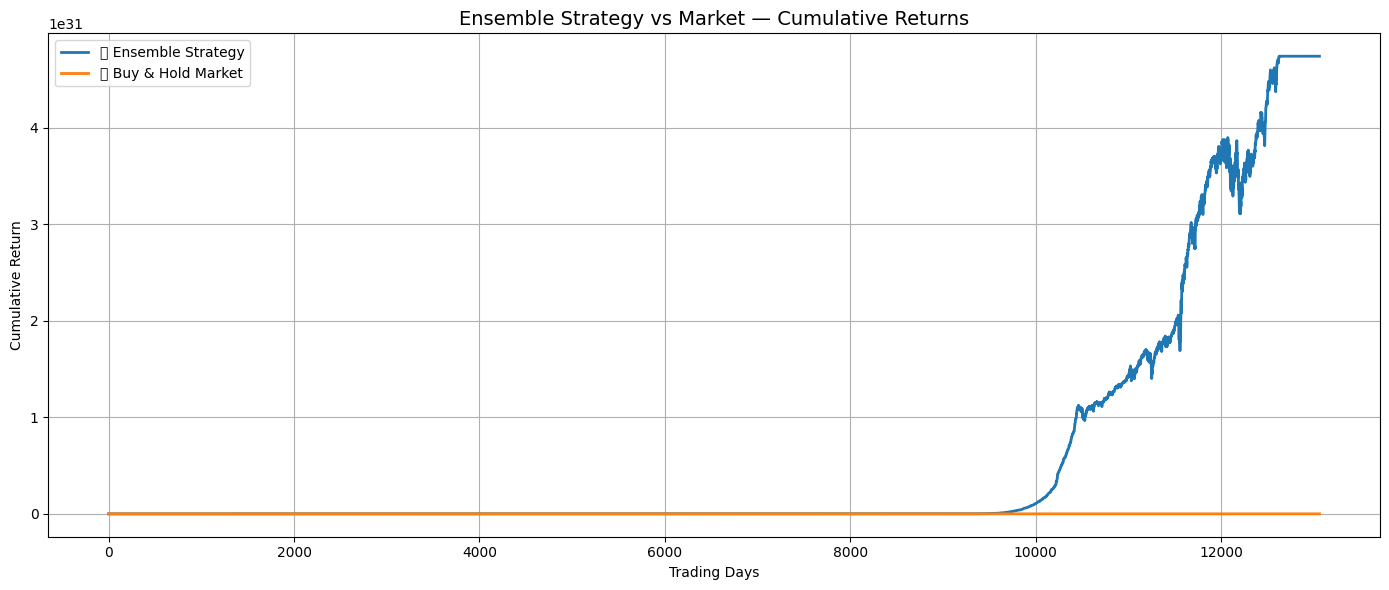

C:\Users\polex\AppData\Local\Temp\ipykernel_3016\2032515238.py:52: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\polex\AppData\Local\Temp\ipykernel_3016\2032515238.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\polex\Desktop\Quant\quant-trading-system\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\polex\Desktop\Quant\quant-trading-system\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


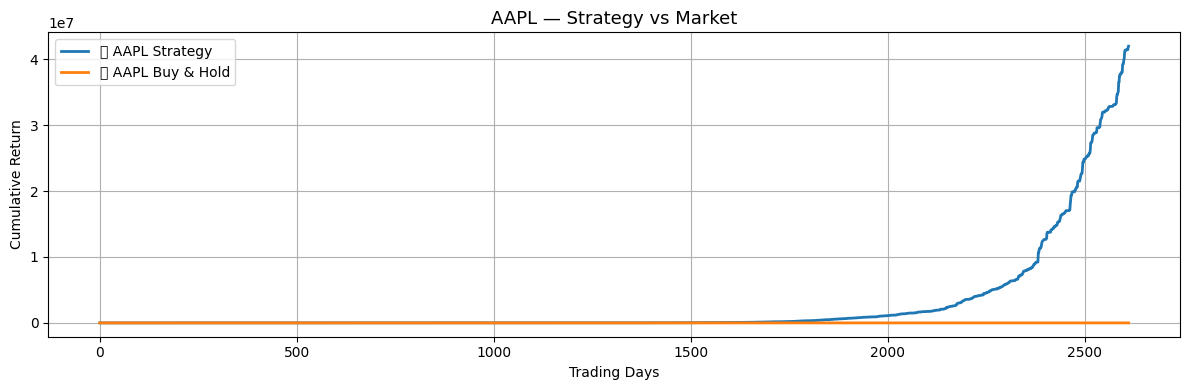

C:\Users\polex\AppData\Local\Temp\ipykernel_3016\2032515238.py:52: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\polex\AppData\Local\Temp\ipykernel_3016\2032515238.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\polex\Desktop\Quant\quant-trading-system\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\polex\Desktop\Quant\quant-trading-system\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


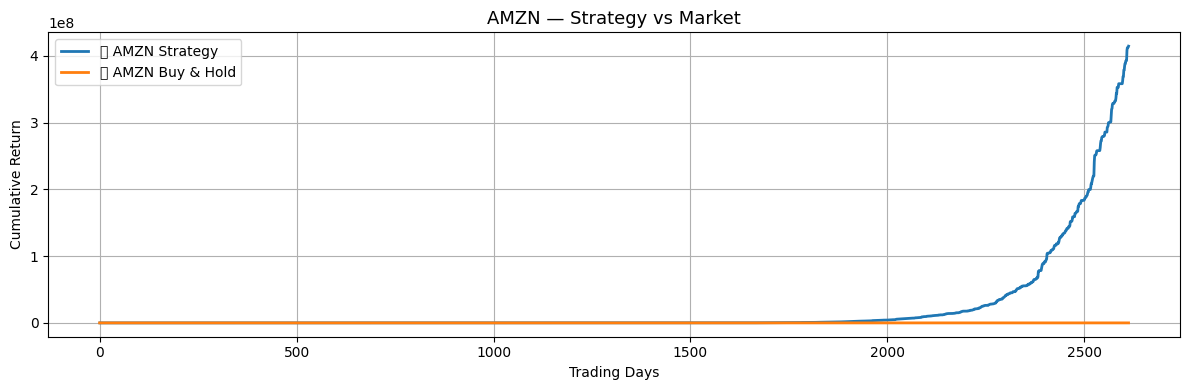

C:\Users\polex\AppData\Local\Temp\ipykernel_3016\2032515238.py:52: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\polex\AppData\Local\Temp\ipykernel_3016\2032515238.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\polex\Desktop\Quant\quant-trading-system\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\polex\Desktop\Quant\quant-trading-system\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


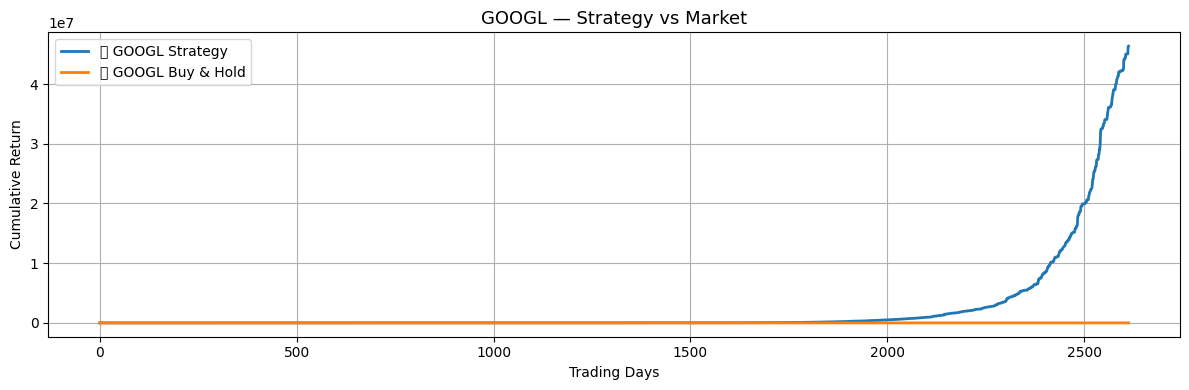

C:\Users\polex\AppData\Local\Temp\ipykernel_3016\2032515238.py:52: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\polex\AppData\Local\Temp\ipykernel_3016\2032515238.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\polex\Desktop\Quant\quant-trading-system\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\polex\Desktop\Quant\quant-trading-system\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


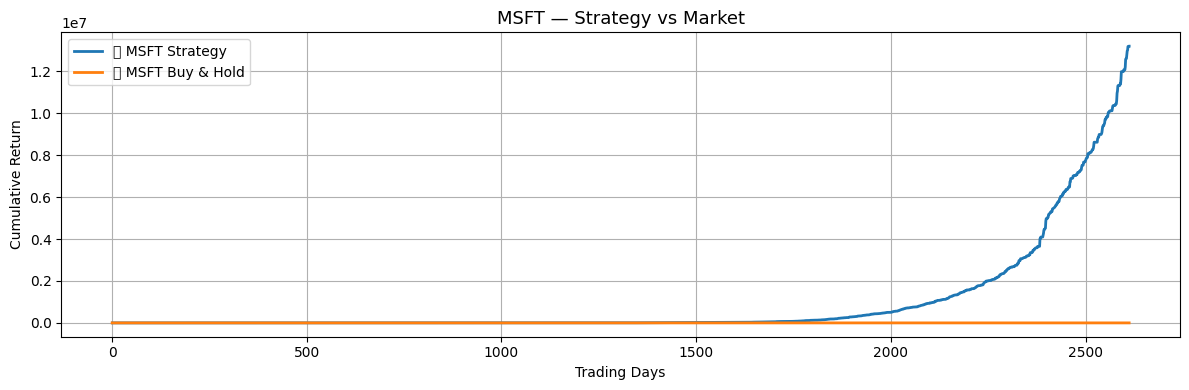

C:\Users\polex\AppData\Local\Temp\ipykernel_3016\2032515238.py:52: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\polex\AppData\Local\Temp\ipykernel_3016\2032515238.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\polex\Desktop\Quant\quant-trading-system\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\polex\Desktop\Quant\quant-trading-system\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


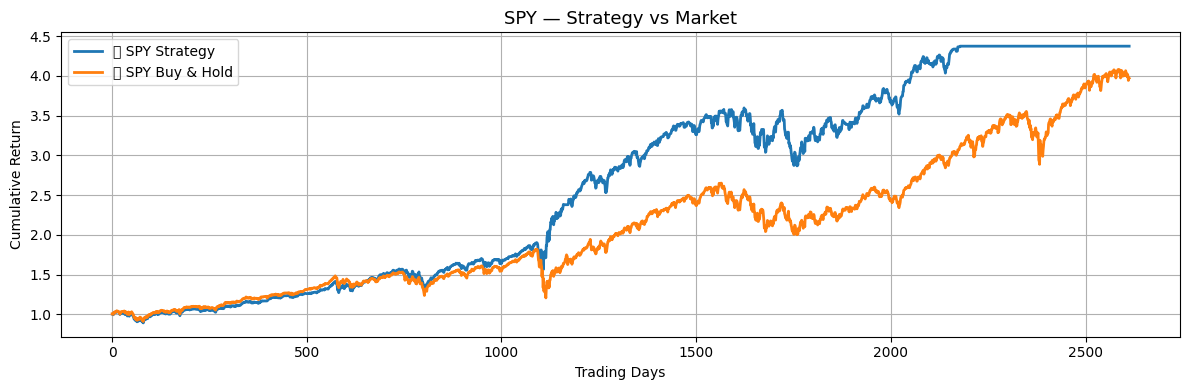

In [23]:
import matplotlib.pyplot as plt

# ── Generate Predictions on ALL data ─────────────────────────────────────────
data['Pred_Prob']   = ensemble.predict_proba(X)[:, 1]
data['Pred_Signal'] = (data['Pred_Prob'] > 0.5).astype(int)

# Shift signal by 1 day (can't trade on same day as prediction)
data['Strategy_Return'] = data['Pred_Signal'].shift(1) * data['Return_1d']
data.dropna(inplace=True)

# ── Cumulative Returns ────────────────────────────────────────────────────────
data['Cum_Strategy'] = (1 + data['Strategy_Return']).cumprod()
data['Cum_Market']   = (1 + data['Return_1d']).cumprod()

# ── Performance Metrics ───────────────────────────────────────────────────────
sharpe   = data['Strategy_Return'].mean() / data['Strategy_Return'].std() * np.sqrt(252)
cum_max  = data['Cum_Strategy'].cummax()
drawdown = (data['Cum_Strategy'] - cum_max) / cum_max

print(f"📈 Sharpe Ratio:   {sharpe:.2f}")
print(f"📉 Max Drawdown:   {drawdown.min():.2%}")
print(f"💰 Total Return:   {data['Cum_Strategy'].iloc[-1]:.2%}")
print(f"📊 Market Return:  {data['Cum_Market'].iloc[-1]:.2%}")

# ── Overall Plot ──────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 6))
plt.plot(data['Cum_Strategy'].values, label='🤖 Ensemble Strategy', linewidth=2)
plt.plot(data['Cum_Market'].values,   label='📊 Buy & Hold Market', linewidth=2)
plt.title("Ensemble Strategy vs Market — Cumulative Returns", fontsize=14)
plt.xlabel("Trading Days")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Per Stock Plot ────────────────────────────────────────────────────────────
if 'Ticker' in data.columns:
    for ticker in data['Ticker'].unique():
        df_t = data[data['Ticker'] == ticker].copy()
        df_t['Cum_Strategy'] = (1 + df_t['Pred_Signal'].shift(1) * df_t['Return_1d']).cumprod()
        df_t['Cum_Market']   = (1 + df_t['Return_1d']).cumprod()

        plt.figure(figsize=(12, 4))
        plt.plot(df_t['Cum_Strategy'].values, label=f'🤖 {ticker} Strategy', linewidth=2)
        plt.plot(df_t['Cum_Market'].values,   label=f'📊 {ticker} Buy & Hold', linewidth=2)
        plt.title(f"{ticker} — Strategy vs Market", fontsize=13)
        plt.xlabel("Trading Days")
        plt.ylabel("Cumulative Return")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [28]:
import joblib

# Save the trained model
joblib.dump(ensemble, 'C:/Users/polex/Desktop/Quant/quant-trading-system/models/ensemble_model.pkl')
print("Model saved!")

Model saved!


In [29]:

## Model for daily prediction
import joblib
import yfinance as yf
import pandas as pd
import numpy as np

# Load the already trained model (no retraining needed!)
ensemble = joblib.load('C:/Users/polex/Desktop/Quant/quant-trading-system/models/ensemble_model.pkl')
print("Model loaded!")

# Then run today's predictions...
tickers = ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'SPY']
raw = yf.download(tickers, period='300d', group_by='ticker', auto_adjust=True)

Model loaded!


[*********************100%***********************]  5 of 5 completed


In [34]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ================================================================
# STEP 1: TRAIN MODEL ON HISTORICAL CSV DATA
# ================================================================
print("Loading historical CSV data...")

csv_path  = "C:/Users/polex/Desktop/Quant/quant-trading-system/features/all_stocks_features.csv"
hist_data = pd.read_csv(csv_path)
hist_data.columns = hist_data.columns.str.strip()

feature_cols = [
    'Return_1d','Return_5d','Return_10d','Return_20d','Log_Return',
    'SMA_10','SMA_20','SMA_50','SMA_200',
    'EMA_10','EMA_20','EMA_50',
    'SMA_10_20_Cross','SMA_20_50_Cross','Price_to_SMA20','Price_to_SMA50',
    'Volatility_10d','Volatility_20d',
    'BB_Mid','BB_Upper','BB_Lower','BB_Width','BB_Pct','ATR_14',
    'RSI_14','RSI_7','MACD','MACD_Signal','MACD_Hist',
    'Stoch_K','Stoch_D','Williams_R','ROC_10','ROC_20',
    'Volume_SMA_20','Volume_Ratio','OBV',
    'High_Low_Range','Body_Size','Gap'
]
feature_cols = [c for c in feature_cols if c in hist_data.columns]

X = hist_data[feature_cols].fillna(0)
y = hist_data['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Training model on historical CSV data...")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

ensemble = VotingClassifier(
    estimators=[('rf', rf_model), ('gb', gb_model), ('lr', lr_model)],
    voting='soft', n_jobs=-1
)

ensemble.fit(X_train, y_train)
y_pred       = ensemble.predict(X_test)
csv_accuracy = accuracy_score(y_test, y_pred)
print("CSV Model Accuracy: " + str(round(csv_accuracy * 100, 2)) + "%")

joblib.dump(ensemble, 'C:/Users/polex/Desktop/Quant/quant-trading-system/models/ensemble_model.pkl')
print("Model saved!")

# ================================================================
# STEP 2: BUILD FEATURES FUNCTION (handles MultiIndex fix)
# ================================================================
def build_features(df):
    df = df.copy()

    # ── FIX: Flatten MultiIndex columns from yfinance ─────────────
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    # Clean column names
    df.columns = [str(c).strip() for c in df.columns]

    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df.dropna(subset=['Close'], inplace=True)

    df['Return_1d']  = df['Close'].pct_change(1)
    df['Return_5d']  = df['Close'].pct_change(5)
    df['Return_10d'] = df['Close'].pct_change(10)
    df['Return_20d'] = df['Close'].pct_change(20)
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

    df['SMA_10']  = df['Close'].rolling(10).mean()
    df['SMA_20']  = df['Close'].rolling(20).mean()
    df['SMA_50']  = df['Close'].rolling(50).mean()
    df['SMA_200'] = df['Close'].rolling(200).mean()
    df['EMA_10']  = df['Close'].ewm(span=10, adjust=False).mean()
    df['EMA_20']  = df['Close'].ewm(span=20, adjust=False).mean()
    df['EMA_50']  = df['Close'].ewm(span=50, adjust=False).mean()

    df['SMA_10_20_Cross'] = (df['SMA_10'] > df['SMA_20']).astype(int)
    df['SMA_20_50_Cross'] = (df['SMA_20'] > df['SMA_50']).astype(int)
    df['Price_to_SMA20']  = df['Close'] / df['SMA_20']
    df['Price_to_SMA50']  = df['Close'] / df['SMA_50']

    df['Volatility_10d'] = df['Log_Return'].rolling(10).std() * np.sqrt(252)
    df['Volatility_20d'] = df['Log_Return'].rolling(20).std() * np.sqrt(252)

    bb_std = df['Close'].rolling(20).std()
    df['BB_Mid']   = df['Close'].rolling(20).mean()
    df['BB_Upper'] = df['BB_Mid'] + 2 * bb_std
    df['BB_Lower'] = df['BB_Mid'] - 2 * bb_std
    df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Mid']
    df['BB_Pct']   = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])

    tr = np.maximum(df['High'] - df['Low'],
         np.maximum(abs(df['High'] - df['Close'].shift(1)),
                    abs(df['Low']  - df['Close'].shift(1))))
    df['ATR_14'] = tr.rolling(14).mean()

    def rsi(s, p=14):
        d = s.diff()
        g = d.clip(lower=0).rolling(p).mean()
        l = (-d.clip(upper=0)).rolling(p).mean()
        return 100 - (100 / (1 + g / (l + 1e-10)))

    df['RSI_14'] = rsi(df['Close'], 14)
    df['RSI_7']  = rsi(df['Close'],  7)

    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD']        = ema12 - ema26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

    sl = df['Low'].rolling(14).min()
    sh = df['High'].rolling(14).max()
    df['Stoch_K']    = 100 * (df['Close'] - sl) / (sh - sl + 1e-10)
    df['Stoch_D']    = df['Stoch_K'].rolling(3).mean()
    df['Williams_R'] = -100 * (sh - df['Close']) / (sh - sl + 1e-10)
    df['ROC_10']     = df['Close'].pct_change(10) * 100
    df['ROC_20']     = df['Close'].pct_change(20) * 100

    df['Volume_SMA_20'] = df['Volume'].rolling(20).mean()
    df['Volume_Ratio']  = df['Volume'] / (df['Volume_SMA_20'] + 1e-10)
    df['OBV']           = (np.sign(df['Close'].diff()) * df['Volume']).fillna(0).cumsum()

    df['High_Low_Range'] = (df['High'] - df['Low']) / df['Close']
    df['Body_Size']      = abs(df['Close'] - df['Open']) / df['Close']
    df['Gap']            = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)

    return df

# ================================================================
# STEP 3: DOWNLOAD LIVE DATA & PREDICT
# ================================================================
tickers   = ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'SPY']
today_str = str(pd.Timestamp.today().date())
results   = []

print("\nDownloading live data from Yahoo Finance...")

for ticker in tickers:
    try:
        # Download one ticker at a time to avoid MultiIndex
        live = yf.download(ticker, period='300d', auto_adjust=True, progress=False)

        # Extra safety -- flatten if still MultiIndex
        if isinstance(live.columns, pd.MultiIndex):
            live.columns = [col[0] for col in live.columns]

        df = build_features(live)
        df.dropna(inplace=True)

        today      = df[feature_cols].fillna(0).iloc[[-1]]
        prob       = ensemble.predict_proba(today)[0][1]
        direction  = "UP" if prob > 0.5 else "DOWN"
        confidence = prob if prob > 0.5 else 1 - prob

        results.append({
            'Ticker'    : ticker,
            'Direction' : direction,
            'Confidence': confidence,
            'Price'     : round(float(df['Close'].iloc[-1]), 2),
            'RSI'       : round(float(df['RSI_14'].iloc[-1]), 1),
            'MACD'      : round(float(df['MACD'].iloc[-1]), 3),
            'BB_Pct'    : round(float(df['BB_Pct'].iloc[-1]), 2),
            'Volatility': round(float(df['Volatility_20d'].iloc[-1]), 3),
            'df'        : df
        })
        print("Done: " + ticker)

    except Exception as e:
        print("ERROR -- " + ticker + " -- " + str(e))

# ================================================================
# STEP 4: SUMMARY TABLE
# ================================================================
print("\n" + "="*65)
print("COMBINED MODEL PREDICTIONS -- " + today_str)
print("Model trained on : Historical CSVs")
print("Live data from   : Yahoo Finance")
print("="*65)
print(f"{'Ticker':<8} {'Direction':<10} {'Confidence':<12} {'Price':<10} {'RSI':<8} {'BB Pct'}")
print("-"*65)

for r in results:
    conf_str  = str(round(r['Confidence'] * 100, 1)) + "%"
    price_str = "$" + str(r['Price'])
    print(f"  {r['Ticker']:<6} {r['Direction']:<10} {conf_str:<12} {price_str:<10} {r['RSI']:<8} {r['BB_Pct']}")

print("="*65)
print("CSV Model Accuracy : " + str(round(csv_accuracy * 100, 2)) + "%")
print("="*65)
print("Note: Predictions are NOT financial advice")
print("="*65)

# ================================================================
# STEP 5: CHARTS FOR EACH STOCK
# ================================================================
for r in results:
    df     = r['df']
    ticker = r['Ticker']

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(
        ticker + " -- " + r['Direction'] +
        " (" + str(round(r['Confidence'] * 100, 1)) + "% confidence) -- " + today_str,
        fontsize=13, fontweight='bold'
    )

    ax1.plot(df['Close'].values,  label='Close',  linewidth=2, color='blue')
    ax1.plot(df['SMA_20'].values, label='SMA 20', linestyle='--', color='orange')
    ax1.plot(df['SMA_50'].values, label='SMA 50', linestyle='--', color='red')
    ax1.fill_between(range(len(df)), df['BB_Upper'].values, df['BB_Lower'].values,
                     alpha=0.1, color='grey', label='Bollinger Bands')
    ax1.set_title("Price, Moving Averages & Bollinger Bands")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(df['RSI_14'].values, label='RSI 14', color='purple', linewidth=2)
    ax2.axhline(70, color='red',   linestyle='--', label='Overbought 70')
    ax2.axhline(30, color='green', linestyle='--', label='Oversold 30')
    ax2.axhline(50, color='grey',  linestyle=':')
    ax2.set_ylim(0, 100)
    ax2.set_title("RSI")
    ax2.legend()
    ax2.grid(True)

    ax3.plot(df['MACD'].values,        label='MACD',        color='blue',   linewidth=2)
    ax3.plot(df['MACD_Signal'].values, label='Signal Line', color='orange', linewidth=2)
    ax3.bar(range(len(df)), df['MACD_Hist'].values,
            label='Histogram',
            color=['green' if v >= 0 else 'red' for v in df['MACD_Hist'].values],
            alpha=0.6)
    ax3.axhline(0, color='black', linestyle='--')
    ax3.set_title("MACD")
    ax3.legend()
    ax3.grid(True)

    plt.tight_layout()
    plt.show()

Loading historical CSV data...
Training model on historical CSV data...


KeyboardInterrupt: 